In [6]:
import pandas as pd
df = pd.read_csv('top-song-durations.csv')
df.head(5)

,year,artist,title,duration
0,2023,Morgan Wallen,Last Night,00:02:43
1,2022,Glass Animals,Heat Waves,00:03:58
2,2021,Dua Lipa,Levitating,00:03:23
3,2020,The Weeknd,Blinding Lights,00:03:20
4,2019,Lil Nas X feat. Billy Ray Cyrus,Old Town Road,00:02:37


In [7]:
# Return the lowest duration
df.query('duration == duration.min()')

,year,artist,title,duration
95,1928,Al Jolson,Sonny Boy,00:01:55


In [8]:
# Use info() to list the data type for each columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   year      101 non-null    int64 
 1   artist    101 non-null    object
 2   title     101 non-null    object
 3   duration  101 non-null    object
dtypes: int64(1), object(3)
memory usage: 3.3+ KB


In [9]:
# Parsing the duration column
split_duration = df['duration'].str.split(':', expand=True)
split_duration.head(5)

,0,1,2
0,00,02,43
1,00,03,58
2,00,03,23
3,00,03,20
4,00,02,37


In [10]:
# Convert values in split_duration to integers using astype()
split_duration = split_duration.astype('int')
split_duration.head(5)

,0,1,2
0,0,2,43
1,0,3,58
2,0,3,23
3,0,3,20
4,0,2,37


In [ ]:
# Confirm converted data types
split_duration.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       101 non-null    int64
 1   1       101 non-null    int64
 2   2       101 non-null    int64
dtypes: int64(3)
memory usage: 2.5 KB


In [12]:
# Naming and adding duration columns to the main dataframe
df[['h', 'm', 's']] = split_duration
df.head(5)

,year,artist,title,duration,h,m,s
0,2023,Morgan Wallen,Last Night,00:02:43,0,2,43
1,2022,Glass Animals,Heat Waves,00:03:58,0,3,58
2,2021,Dua Lipa,Levitating,00:03:23,0,3,23
3,2020,The Weeknd,Blinding Lights,00:03:20,0,3,20
4,2019,Lil Nas X feat. Billy Ray Cyrus,Old Town Road,00:02:37,0,2,37


In [13]:
# Calculating total seconds
df['total_seconds'] = df.eval('h*3600 + m*60 + s')
df.head(5)

,year,artist,title,duration,h,m,s,total_seconds
0,2023,Morgan Wallen,Last Night,00:02:43,0,2,43,163
1,2022,Glass Animals,Heat Waves,00:03:58,0,3,58,238
2,2021,Dua Lipa,Levitating,00:03:23,0,3,23,203
3,2020,The Weeknd,Blinding Lights,00:03:20,0,3,20,200
4,2019,Lil Nas X feat. Billy Ray Cyrus,Old Town Road,00:02:37,0,2,37,157


Text(0, 0.5, 'Duration (Seconds)')

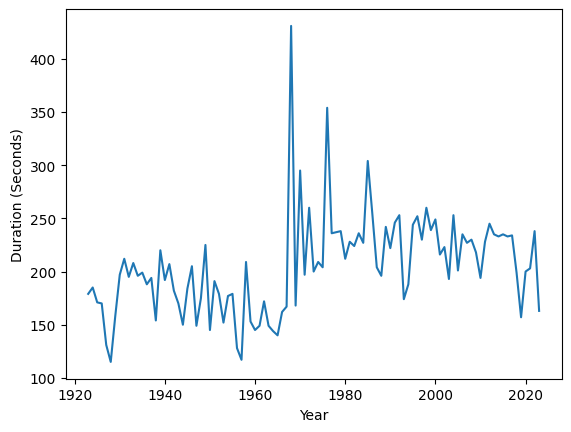

In [17]:
# Plot top-hit song duration

import matplotlib.pyplot as plt

plt.plot(df['year'], df['total_seconds'])
plt.xlabel('Year')
plt.ylabel('Duration (Seconds)')

In [19]:
df.query('total_seconds == total_seconds.max()')

,year,artist,title,duration,h,m,s,total_seconds
55,1968,The Beatles,Hey Jude,00:07:11,0,7,11,431
